Uma companhia de transporte tem dois tipos de caminhões: 
- O tipo “A” tem 2m3 de espaço refrigerado e 3m3 de espaço não refrigerado
- o tipo “B” tem 2m3 de espaço refrigerado e 1m3 de não refrigerado.

O cliente quer transportar um produto que necessita 16m3 de área refrigerada e 12 m3 de área não refrigerada.

A companhia calcula em 1.100l o combustível para uma viagem com o caminhão “A” e 750l para o caminhão “B”.

Quantos caminhões de cada tipo deverão ser usados no transporte do
produto, com o menor consumo de combustível?

- Variáveis de decisão:
    - x1 = número de caminhões tipo A
    - x2 = número de caminhões tipo B
 
- Função objetivo:
    - Min Z = 1100·x1 + 750·x2
 
- Restrições (≥ : precisamos de PELO MENOS esse espaço):
    - R1 — refrigerado     : 2x1 + 2x2 ≥ 16  →  x1 + x2 ≥ 8
    - R2 — não refrigerado : 3x1 +  x2 ≥ 12
    - R3 — não-negatividade: x1 ≥ 0,  x2 ≥ 0
 

In [1]:
# Minimizar o combustivel
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import linprog

In [3]:
res = linprog(
    c    = [1100, 750],
    A_ub = [[-1, -1],    # -(x1+x2) ≤ -8
            [-3, -1]],   # -(3x1+x2) ≤ -12
    b_ub = [-8, -12],
    bounds = [(0, None), (0, None)],
    method = 'highs'
)

In [4]:
print(f"  x1 = {res.x[0]:.6f}  x2 = {res.x[1]:.6f}")
print(f"  Z  = {res.fun:.6f} L")
print(f"  Status: {res.message}")
 

  x1 = 2.000000  x2 = 6.000000
  Z  = 6700.000000 L
  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)


Uma empresa de mineração deseja cumprir um contrato de fornecimento de 4 milhões de toneladas por ano do minério Sinter Feed e, para tanto, conta com os seguintes minérios (a tabela abaixo mostra a composição percentual e o custo/t. de cada minério):

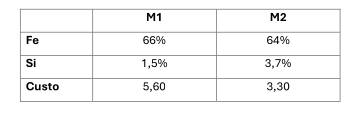

O minério a ser produzido por esse blending deve conter no mínimo 65% de ferro e no máximo 3% de silício. Qual é o blending a custo mínimo?

  BLENDING DE MINÉRIO — Programação Linear (Min custo)

--- Análise algébrica (x₂ = 1 − x₁) ---

Substituindo x₂ = 1 − x₁ em cada restrição:

R1 (Fe ≥ 65%):
  66x₁ + 64(1−x₁) ≥ 65
  66x₁ + 64 − 64x₁ ≥ 65
  2x₁ ≥ 1  →  x₁ ≥ 0,5

R2 (Si ≤ 3%):
  1,5x₁ + 3,7(1−x₁) ≤ 3
  1,5x₁ + 3,7 − 3,7x₁ ≤ 3
  −2,2x₁ ≤ −0,7
  x₁ ≥ 0,7/2,2 = 7/22 ≈ 0,3182

Região viável: x₁ ∈ [0,5 ; 1,0]
Função objetivo: Z = 5,60x₁ + 3,30(1−x₁) = 3,30 + 2,30x₁

Como o coeficiente de x₁ é POSITIVO (2,30 > 0),
Z cresce com x₁  →  mínimo em x₁ = 0,5 (menor valor viável).

Solução analítica: x₁ = 0.5, x₂ = 0.5, Z = $ 4.45/t

--- Método numpy: vértices da região viável ---
  x₁=0.500000  x₂=0.500000  Z=$4.4500/t  [R1-Fe]
  x₁=1.000000  x₂=0.000000  Z=$5.6000/t  [x₂=0, x₁=1]

--- Confirmação scipy.linprog ---
  x₁ = 0.50000000  x₂ = 0.50000000
  Z  = $ 4.450000/t  |  Optimization terminated successfully. (HiGHS Status 7: Optimal)

  RESULTADO FINAL

Blending ótimo (frações):
  M1 : 50.00%  →  2.00 Mi t/ano
  M2 : 50.00%  →  2.

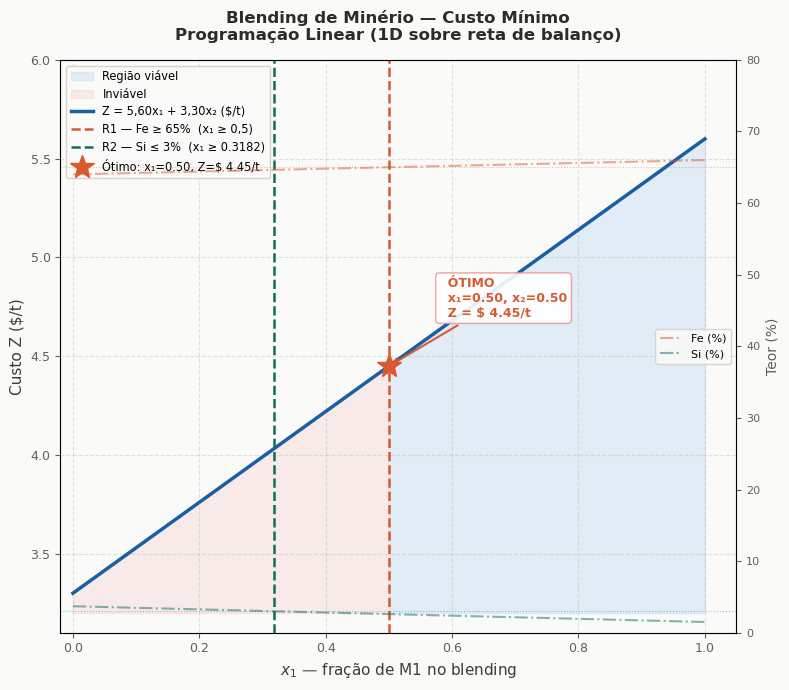


Gráfico salvo.


In [ ]:
"""
Programação Linear — Blending de Minério (Minimização)
=======================================================

Variáveis de decisão (FRAÇÕES da mistura total):
    x1 = fração de M1 no blending
    x2 = fração de M2 no blending

    x1 + x2 = 1  (100% da mistura)

Função objetivo (custo por tonelada):
    Min Z = 5,60·x1 + 3,30·x2

Restrições de qualidade:
    R1 — Fe ≥ 65% : 66x1 + 64x2 ≥ 65
    R2 — Si ≤  3% : 1,5x1 + 3,7x2 ≤ 3
    R3 — balanço  : x1 + x2 = 1
    R4 — não-neg. : x1 ≥ 0, x2 ≥ 0


"""

CONTRATO = 4_000_000   # toneladas/ano

print("=" * 60)
print("  BLENDING DE MINÉRIO — Programação Linear (Min custo)")
print("=" * 60)

# -------------------------------------------------------
# 1. ANÁLISE ALGÉBRICA — substituição x2 = 1 - x1
# -------------------------------------------------------
print("\n--- Análise algébrica (x₂ = 1 − x₁) ---")
print("""
Substituindo x₂ = 1 − x₁ em cada restrição:

R1 (Fe ≥ 65%):
  66x₁ + 64(1−x₁) ≥ 65
  66x₁ + 64 − 64x₁ ≥ 65
  2x₁ ≥ 1  →  x₁ ≥ 0,5

R2 (Si ≤ 3%):
  1,5x₁ + 3,7(1−x₁) ≤ 3
  1,5x₁ + 3,7 − 3,7x₁ ≤ 3
  −2,2x₁ ≤ −0,7
  x₁ ≥ 0,7/2,2 = 7/22 ≈ 0,3182

Região viável: x₁ ∈ [0,5 ; 1,0]
Função objetivo: Z = 5,60x₁ + 3,30(1−x₁) = 3,30 + 2,30x₁

Como o coeficiente de x₁ é POSITIVO (2,30 > 0),
Z cresce com x₁  →  mínimo em x₁ = 0,5 (menor valor viável).
""")
x1_analitico = 0.5
x2_analitico = 0.5
Z_analitico  = 5.60 * x1_analitico + 3.30 * x2_analitico
print(f"Solução analítica: x₁ = {x1_analitico}, x₂ = {x2_analitico}, Z = $ {Z_analitico:.2f}/t")

# -------------------------------------------------------
# 2. NUMPY — método dos vértices (forma matricial completa)
# -------------------------------------------------------
print("\n--- Método numpy: vértices da região viável ---")

# Fronteiras (ax1 + bx2 = c):
#   x1=0, x2=0, x1+x2=1, 66x1+64x2=65, 1.5x1+3.7x2=3
fronteiras = [
    (1,   0,   0),      # x1 = 0
    (0,   1,   0),      # x2 = 0
    (1,   1,   1),      # balanço
    (66,  64,  65),     # R1 Fe = 65 (fronteira)
    (1.5, 3.7, 3),      # R2 Si = 3  (fronteira)
]

def intersect_np(l1, l2):
    A = np.array([l1[:2], l2[:2]], dtype=float)
    b = np.array([l1[2],  l2[2]], dtype=float)
    if abs(np.linalg.det(A)) < 1e-12:
        return None
    return np.linalg.solve(A, b)

def is_feasible(px, py, tol=1e-9):
    return (px >= -tol and py >= -tol and
            abs(px + py - 1) < 1e-6 and          # balanço
            66*px + 64*py >= 65 - tol and         # Fe ≥ 65
            1.5*px + 3.7*py <= 3 + tol)            # Si ≤ 3

candidatos = []
for l1, l2 in combinations(fronteiras, 2):
    pt = intersect_np(l1, l2)
    if pt is not None:
        px, py = np.round(pt, 10)
        if is_feasible(px, py):
            candidatos.append((round(px,8), round(py,8)))

# Remove duplicatas
arr = np.array(candidatos)
_, idx = np.unique(np.round(arr, 6), axis=0, return_index=True)
vertices = arr[idx]

melhor_Z  = np.inf
melhor_pt = None
for vx, vy in vertices:
    zv = 5.60*vx + 3.30*vy
    ativo = []
    if abs(vx) < 1e-6:              ativo.append("x₁=0")
    if abs(vy) < 1e-6:              ativo.append("x₂=0")
    if abs(vx-1) < 1e-6:           ativo.append("x₁=1")
    if abs(vy-1) < 1e-6:           ativo.append("x₂=1")
    if abs(66*vx+64*vy-65) < 1e-4: ativo.append("R1-Fe")
    if abs(1.5*vx+3.7*vy-3) < 1e-4:ativo.append("R2-Si")
    print(f"  x₁={vx:.6f}  x₂={vy:.6f}  Z=${zv:.4f}/t  [{', '.join(ativo)}]")
    if zv < melhor_Z:
        melhor_Z  = zv
        melhor_pt = (vx, vy)

x1_opt, x2_opt = melhor_pt

# -------------------------------------------------------
# 3. CONFIRMAÇÃO SCIPY
# -------------------------------------------------------
print(f"\n--- Confirmação scipy.linprog ---")
res = linprog(
    c     = [5.60, 3.30],
    A_ub  = [[-66, -64],       # R1: -(66x1+64x2) ≤ -65
             [1.5, 3.7]],      # R2: 1.5x1+3.7x2 ≤ 3
    b_ub  = [-65, 3],
    A_eq  = [[1, 1]],          # balanço: x1+x2 = 1
    b_eq  = [1],
    bounds= [(0,1),(0,1)],
    method= 'highs'
)
print(f"  x₁ = {res.x[0]:.8f}  x₂ = {res.x[1]:.8f}")
print(f"  Z  = $ {res.fun:.6f}/t  |  {res.message}")

# -------------------------------------------------------
# 4. RESULTADO FINAL
# -------------------------------------------------------
print(f"\n{'='*60}")
print("  RESULTADO FINAL")
print(f"{'='*60}")
fe_blend = 66*x1_opt + 64*x2_opt
si_blend = 1.5*x1_opt + 3.7*x2_opt
vol_M1   = x1_opt * CONTRATO
vol_M2   = x2_opt * CONTRATO
custo_t  = melhor_Z
custo_total = custo_t * CONTRATO

print(f"\nBlending ótimo (frações):")
print(f"  M1 : {x1_opt*100:.2f}%  →  {vol_M1/1e6:.2f} Mi t/ano")
print(f"  M2 : {x2_opt*100:.2f}%  →  {vol_M2/1e6:.2f} Mi t/ano")
print(f"\nQualidade do blending:")
print(f"  Fe : {fe_blend:.4f}%  (mínimo exigido: 65%)  {'✓' if fe_blend >= 65-1e-9 else '✗'}")
print(f"  Si : {si_blend:.4f}%  (máximo exigido:  3%)  {'✓' if si_blend <= 3+1e-9 else '✗'}")
print(f"\nCusto:")
print(f"  Por tonelada   : $ {custo_t:.2f}/t")
print(f"  Total anual    : $ {custo_total:,.2f}  ({CONTRATO/1e6:.0f} Mi t × $ {custo_t:.2f})")

# -------------------------------------------------------
# 5. GRÁFICO
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x1v = np.linspace(0, 1, 600)
x2v = 1 - x1v   # x2 = 1 - x1 (balanço obrigatório)

# Fe e Si como função de x1 (ao longo da reta x1+x2=1)
fe_v = 66*x1v + 64*x2v
si_v = 1.5*x1v + 3.7*x2v

# ── Painel superior: composição vs x1 ──────────────────
ax2 = ax.twinx()
ax2.plot(x1v, fe_v, color='#D85A30', lw=1.5, linestyle='-.', alpha=0.5, label='Fe (%)')
ax2.plot(x1v, si_v, color='#0F6E56', lw=1.5, linestyle='-.', alpha=0.5, label='Si (%)')
ax2.axhline(65, color='#D85A30', lw=0.8, linestyle=':', alpha=0.4)
ax2.axhline(3,  color='#0F6E56', lw=0.8, linestyle=':', alpha=0.4)
ax2.set_ylabel('Teor (%)', fontsize=10, color='#5F5E5A')
ax2.tick_params(colors='#5F5E5A', labelsize=8)
ax2.set_ylim(0, 80)
ax2.legend(loc='center right', fontsize=8, framealpha=0.85,
           edgecolor='#D3D1C7', facecolor='#FAFAF8')

# ── Custo ao longo da reta de balanço ──────────────────
z_v = 5.60*x1v + 3.30*x2v

# Região viável: x1 ∈ [0.5, 1]
mask_viavel = (x1v >= 0.5 - 1e-9) & (x1v <= 1 + 1e-9)
mask_inviavel = ~mask_viavel

ax.fill_between(x1v[mask_viavel], z_v[mask_viavel],
                np.full(mask_viavel.sum(), z_v.min() - 0.1),
                color='#B5D4F4', alpha=0.35, label='Região viável')
ax.fill_between(x1v[mask_inviavel], z_v[mask_inviavel],
                np.full(mask_inviavel.sum(), z_v.min() - 0.1),
                color='#F09595', alpha=0.15, label='Inviável')

ax.plot(x1v, z_v, color='#185FA5', lw=2.5, label='Z = 5,60x₁ + 3,30x₂ ($/t)')

# Linhas verticais das restrições
ax.axvline(0.5, color='#D85A30', lw=1.8, linestyle='--',
           label='R1 — Fe ≥ 65%  (x₁ ≥ 0,5)')
x1_si = 7/22
ax.axvline(x1_si, color='#0F6E56', lw=1.8, linestyle='--',
           label=f'R2 — Si ≤ 3%  (x₁ ≥ {x1_si:.4f})')

# Ponto ótimo
z_opt_plot = 5.60*x1_opt + 3.30*x2_opt
ax.plot(x1_opt, z_opt_plot, '*', color='#D85A30', ms=18, zorder=6,
        label=f'Ótimo: x₁={x1_opt:.2f}, Z=$ {z_opt_plot:.2f}/t')
ax.annotate(
    f'  ÓTIMO\n  x₁={x1_opt:.2f}, x₂={x2_opt:.2f}\n  Z = $ {z_opt_plot:.2f}/t',
    xy=(x1_opt, z_opt_plot),
    xytext=(x1_opt + 0.08, z_opt_plot + 0.25),
    fontsize=9, color='#D85A30', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#F09595', alpha=0.9)
)

ax.set_xlim(-0.02, 1.05)
ax.set_ylim(3.1, 6.0)
ax.set_xlabel('$x_1$ — fração de M1 no blending', fontsize=11, color='#3d3d3a')
ax.set_ylabel('Custo Z ($/t)', fontsize=11, color='#3d3d3a')
ax.set_title('Blending de Minério — Custo Mínimo\nProgramação Linear (1D sobre reta de balanço)',
             fontsize=12, fontweight='bold', color='#2C2C2A', pad=14)
ax.grid(True, linestyle='--', alpha=0.35, color='#B4B2A9')
ax.tick_params(colors='#5F5E5A', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#D3D1C7')
ax.legend(loc='upper left', fontsize=8.2,
          framealpha=0.92, edgecolor='#D3D1C7', facecolor='#FAFAF8')

plt.tight_layout()
plt.show()
print("\nGráfico salvo.")
plt.close()